Dataset shape: (29768, 2376)
Labels shape: (29768,)
Unique emotions: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']
X_train shape: (23814, 2376, 1, 1), X_test shape: (5954, 2376, 1, 1)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 2374, 1, 64)    │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1187, 1, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1187, 1, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1185, 1, 128)   │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 592, 1, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 592, 1, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 75776)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     9,699,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,725,190 (37.10 MB)

 Trainable params: 9,725,190 (37.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1683 - loss: 1.8519 - val_accuracy: 0.1676 - val_loss: 1.7899
Epoch 2/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.1693 - loss: 1.7907 - val_accuracy: 0.1643 - val_loss: 1.7899
Epoch 3/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.1721 - loss: 1.7905 - val_accuracy: 0.1676 - val_loss: 1.7899
Epoch 4/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1719 - loss: 1.7905 - val_accuracy: 0.1643 - val_loss: 1.7899
Epoch 5/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.1667 - loss: 1.7906 - val_accuracy: 0.1643 - val_loss: 1.7898
Epoch 6/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1691 - loss: 1.7905 - val_accuracy: 0.1643 - val_loss: 1.7897
Epoch 7/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.1670 - loss: 1.7905 - val_accuracy: 0.1643 - val_loss: 1.7900
Epoch 8/30
745/745 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.1665 - loss: 1.7906 - 

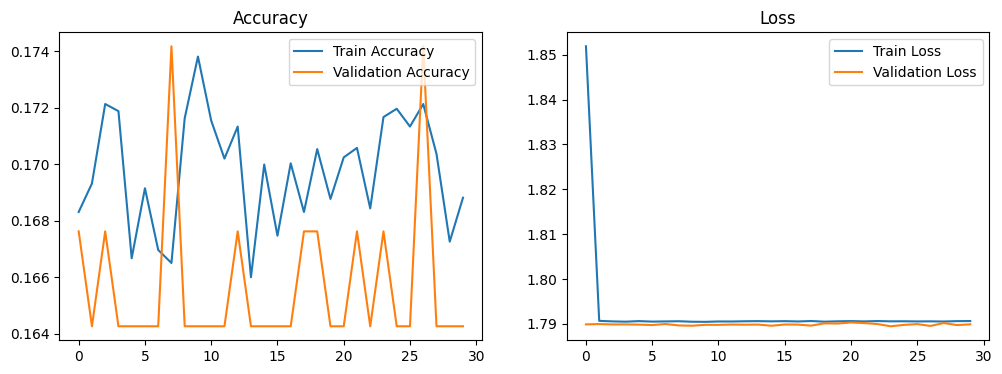

In [5]:
# ================================
# Speech Emotion Recognition using CNN
# Single-Cell Jupyter Notebook Code
# ================================

# Install required libraries (run once)
!pip install librosa numpy matplotlib scikit-learn tensorflow pandas

# ----------------
# Import Libraries
# ----------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

# ----------------
# Load Pre-processed Dataset
# ----------------
# Load the pre-processed features from CSV
data_path = "processed_data.csv"
df = pd.read_csv(data_path)

# Separate features and labels
X = df.iloc[:, :-1].values  # All columns except the last one (features)
y = df.iloc[:, -1].values    # Last column (emotions)

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Unique emotions: {np.unique(y)}")

# ----------------
# Encode Labels
# ----------------
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# ----------------
# Train-Test Split
# ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

# ----------------
# Reshape for CNN
# ----------------
# Reshape data based on actual feature dimensions
n_features = X_train.shape[1]
X_train = X_train.reshape(X_train.shape[0], n_features, 1, 1)
X_test = X_test.reshape(X_test.shape[0], n_features, 1, 1)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# ----------------
# CNN Model
# ----------------
model = Sequential()

model.add(Conv2D(64, (3,1), activation='relu', input_shape=(n_features,1,1)))
model.add(MaxPooling2D((2,1)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3,1), activation='relu'))
model.add(MaxPooling2D((2,1)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ----------------
# Train Model
# ----------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ----------------
# Evaluate Model
# ----------------
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# ----------------
# Plot Accuracy & Loss
# ----------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

# ----------------
# Predict Emotion
# ----------------
def predict_emotion(file_path):
    features = extract_features(file_path)
    features = features.reshape(1, n_features, 1, 1)
    prediction = model.predict(features)
    emotion = encoder.inverse_transform([np.argmax(prediction)])
    return emotion[0]

# Example Prediction
# print(predict_emotion("test_audio.wav"))
